<div align="right">iX Program 2025 | Data Science | Week 1 | Class 5 | NB1 </div>

# Introduction to Scikit-learn API

####  List of exercises
>  - **Exercise 1:** From Spores to Scores: Predicting Mushroom Edibility with Classification Models (100).

## What is `scikit-learn`?


- An open source machine learning library that supports supervised and unsupervised learning. 
- Provides various tools for:
   - Data preprocessing
   - Data transformation
   - Feature selection
   - Model fitting
   - Model selection
   - Model evaluation
   - Utilities for building reusable and clean ML workflows
   - Model persistence
   - Estimator composition
   - Utilities for inspection and debugging
   - Toy datasets

## Understanding the core components of the scikit-learn interface

### 1. Import Required Libraries

In [0]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pylab as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

### 2. The Dataset API

- Scikit-learn's built-in dataset loaders (e.g., `load_iris()`, `load_diabetes()`, etc.) return a **Bunch object**, which behaves like a dictionary. Most of them consistently include:

   `.data` — feature matrix (NumPy array)

   `.target` — target vector (NumPy array)

   `.target_names` — names of classes or outputs (if applicable)

   `.feature_names` — list of feature names (in most, but not all, datasets)

   `.DESCR` — dataset description

- This is helpful for:
   - Exploratory Data Analysis (EDA)
   - Visualizations (e.g., plotting with Seaborn or Matplotlib)
   - Feature inspection and selection

In [0]:
data = load_iris()
X = data.data
y_enc = data.target

print("Feature names:", data.feature_names)
print("Target classes:", data.target_names)

In [0]:
# Map numeric targets to names using list comprehension
target_names = [str(name) for name in data.target_names]
y = [target_names[i] for i in y_enc]
y

### 3.  Estimators
- Scikit-learn provides dozens of built-in machine learning algorithms and models, called **estimators**. 
- Each estimator APIs follow a consistent design:
   1. `.fit()` - learns from training data
   2. `.transform()` - modifies data (for transformers)
   3. `.predict()` - makes predictions (for predictors)

#### 3.1 Data Preprocessing - Train/Test Split

In [0]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [0]:
y_train

#### 3.2 Example of a Transformer (StandardScaler)

In [0]:
scaler = StandardScaler() # instantiate transformer
scaler.fit(X_train)      # learn scaling params
X_train_scaled = scaler.transform(X_train)  # apply transform
X_test_scaled = scaler.transform(X_test)    # apply same transform to test data

#### 3.3 Example of an Predictor Estimator (LogisticRegression)

In [0]:
model = LogisticRegression(max_iter=200)   # instantiate estimator
model.fit(X_train_scaled, y_train)         # fit or train model using train data
predictions = model.predict(X_test_scaled) # predict on test data

#### 3.4 Model Evaluation
- Fitting a model to some data does not entail that it will predict well on unseen data. 
- This needs to be directly evaluated. 
- The train_test_split helper splits a dataset into train and test sets
- We use the test (or hold-out) sample for an *unbiased* assessment of how well the model might if applied to new data 

In [0]:
print(f"Test Accuracy: {np.round(100*accuracy_score(y_test, predictions),1)}%")

In [0]:
# evaluate confusion matrix
cm = confusion_matrix(y_test, predictions)

In [0]:
print(cm)

In [0]:
# specify labels ordering
labels = ['setosa', 'versicolor', 'virginica']

In [0]:
# Create annotated heatmap
_ = sns.heatmap(
    cm,
    annot=True,         # write values in the boxes
    fmt=".2f",          # format decimal places
    cmap="coolwarm",    # color palette
    xticklabels=labels,
    yticklabels=labels
)

In [0]:
# normalize by row (i.e., by the true class counts)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

In [0]:
# Create annotated heatmap
_ = sns.heatmap(
    cm_normalized,
    annot=True,         # write values in the boxes
    fmt=".2f",          # format decimal places
    cmap="coolwarm",    # color palette
    xticklabels=labels,
    yticklabels=labels
)

In [0]:
# classification report
print("\nClassification Report:\n", classification_report(y_test, predictions))

### 4. Chaining pre-processors and estimators

- Transformers and estimators (predictors) can be combined together into a single unifying object: a `Pipeline`. 
- A Pipeline is an estimator, offers the same API as a regular estimator, i.e. `.fit()` and `.predict()` methods.
- Using a pipeline will also prevent you from data leakage, i.e. disclosing some testing data in your training data.

In [0]:

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=200))
])

pipeline.fit(X_train, y_train)
pipeline_predictions = pipeline.predict(X_test)

print(f"Pipeline Test Accuracy: {np.round(100*accuracy_score(y_test, pipeline_predictions),1)}%")

cm_pipeline = confusion_matrix(y_test, pipeline_predictions)
cm_pipeline_normalized = cm_pipeline.astype('float') / cm.sum(axis=1)[:, np.newaxis]

In [0]:
# Create annotated heatmap
_ = sns.heatmap(
    cm_pipeline,
    annot=True,         # write values in the boxes
    fmt=".2f",          # format decimal places
    cmap="coolwarm",    # color palette
    xticklabels=labels,
    yticklabels=labels
)


In [0]:
# Create annotated heatmap
_ = sns.heatmap(
    cm_pipeline_normalized,
    annot=True,         # write values in the boxes
    fmt=".2f",          # format decimal places
    cmap="coolwarm",    # color palette
    xticklabels=labels,
    yticklabels=labels
)

### 5. Summary of the scikit-learn API:
- Consistent interface for all models: `.fit()`, `.predict()`, `.transform()`
- Transformers modify data (e.g., StandardScaler)
- Predictors make predictions (e.g., LogisticRegression)
- Pipelines chain multiple steps into a single object with a clean interface

<br>
<div class="alert alert-info">
<b style="font-size: 25px"> Exercise 1: From Spores to Scores: Predicting Mushroom Edibility with Classification Models</b>
</div>

### Objective:
- Explore the categorical features in the mushrooms dataset to determine which ones are most useful for distinguishing edible from poisonous mushrooms.
- Build a classification model

### Dataset
Source: [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/Mushroom)

This dataset includes descriptions of hypothetical samples corresponding to 23 species of gilled mushrooms in the Agaricus and Lepiota Family Mushroom drawn from The Audubon Society Field Guide to North American Mushrooms (1981). Each species is identified as definitely edible, definitely poisonous, or of unknown edibility and not recommended. This latter class was combined with the poisonous one. The Guide clearly states that there is no simple rule for determining the edibility of a mushroom; no rule like "leaflets three, let it be'' for Poisonous Oak and Ivy.


**Attribute Information:** 

(classes: edible=e, poisonous=p)\
cap-shape: bell=b,conical=c,convex=x,flat=f, knobbed=k,sunken=s\
cap-surface: fibrous=f,grooves=g,scaly=y,smooth=s\
cap-color: brown=n,buff=b,cinnamon=c,gray=g,green=r,pink=p,purple=u,red=e,white=w,yellow=y\
bruises: bruises=t,no=f\
odor: almond=a,anise=l,creosote=c,fishy=y,foul=f,musty=m,none=n,pungent=p,spicy=s\
gill-attachment: attached=a,descending=d,free=f,notched=n\
gill-spacing: close=c,crowded=w,distant=d\
gill-size: broad=b,narrow=n\
gill-color: black=k,brown=n,buff=b,chocolate=h,gray=g, green=r,orange=o,pink=p,purple=u,red=e,white=w,yellow=y\
stalk-shape: enlarging=e,tapering=t\
stalk-root: bulbous=b,club=c,cup=u,equal=e,rhizomorphs=z,rooted=r,missing=?\
stalk-surface-above-ring: fibrous=f,scaly=y,silky=k,smooth=s\
stalk-surface-below-ring: fibrous=f,scaly=y,silky=k,smooth=s\
stalk-color-above-ring: brown=n,buff=b,cinnamon=c,gray=g,orange=o,pink=p,red=e,white=w,yellow=y\
stalk-color-below-ring: brown=n,buff=b,cinnamon=c,gray=g,orange=o,pink=p,red=e,white=w,yellow=y\
veil-type: partial=p,universal=u\
veil-color: brown=n,orange=o,white=w,yellow=y\
ring-number: none=n,one=o,two=t\
ring-type: cobwebby=c,evanescent=e,flaring=f,large=l,none=n,pendant=p,sheathing=s,zone=z\
spore-print-color: black=k,brown=n,buff=b,chocolate=h,green=r,orange=o,purple=u,white=w,yellow=y\
population: abundant=a,clustered=c,numerous=n,scattered=s,several=v,solitary=y\
habitat: grasses=g,leaves=l,meadows=m,paths=p,urban=u,waste=w,woods=d\

### Instructions
1. Load and Inspect the Data
2. Explore Feature Distributions by Class for all Categorical Features
   - For each plot:
      - Is there a clear difference in value distribution between edible and poisonous mushrooms?
      - Which values seem strongly associated with being poisonous?
3. Use `Pandas` `crosstab` function (with parameter `normalize='index'`) to quantify separation of at least 6 of the features you analyzed from the previous question that you think (through visualization) are more discriminative. 
   - Which categories are almost always poisonous?
   - Are there any features where the classes are evenly mixed?
4. Identify Top Discriminative Features
   - Identify at least 3 features that:
      - Show distinct class separation
      - Could help a classifier tell edible from poisonous mushrooms
   - Justify your choices using plots or tables.
5. Split your dataset into a train set (80%) and a test set (20%)
6. Fit a `DecisionTreeClassifier()` model to the data. (Use `from sklearn.tree import DecisionTreeClassifier` to access `DecisionTreeClassifier` model.)
7. What is the model's accuracy on the test data?
8. Show and intepret the confusion matrix.
9. Print the summary classification report for your model.
10. Decision Trees can be used to rank the predictive strengths of the features used in training the model. These can be accessed using `.feature_importances_` from your fitted model.
   - Create a `Pandas` `Series` object from these feature importance values, where the index values are the feature names (available in `X.columns`).
   - Using native Pandas methods accessible from the `Series` object you just created, sort the values in ascending order, and plot a horizontal bar plot whose title is 'Feature Importance'.
   - Compare your top feature choices from the EDA above with the top features identified using a decision tree model.

<br>
<div class="alert alert-info">
  <b style="font-size: 25px;">Your Solution Here</b>
</div>

class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,stalk-root,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
p,x,s,n,t,p,f,c,n,k,e,e,s,s,w,w,p,w,o,p,k,s,u
e,x,s,y,t,a,f,c,b,k,e,c,s,s,w,w,p,w,o,p,n,n,g
e,b,s,w,t,l,f,c,b,n,e,c,s,s,w,w,p,w,o,p,n,n,m
p,x,y,w,t,p,f,c,n,n,e,e,s,s,w,w,p,w,o,p,k,s,u
e,x,s,g,f,n,f,w,b,k,t,e,s,s,w,w,p,w,o,e,n,a,g


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

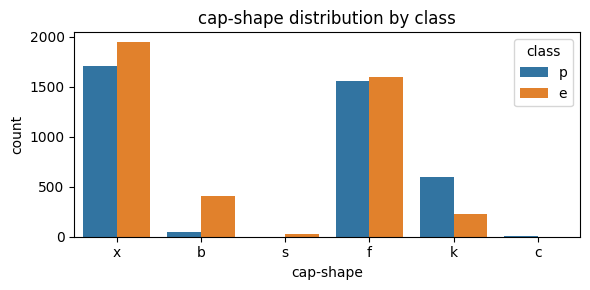

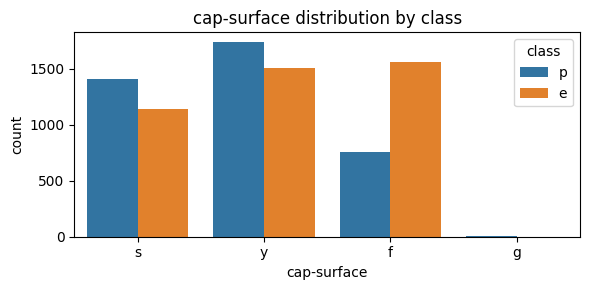

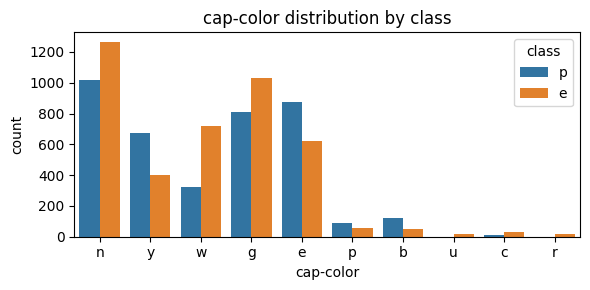

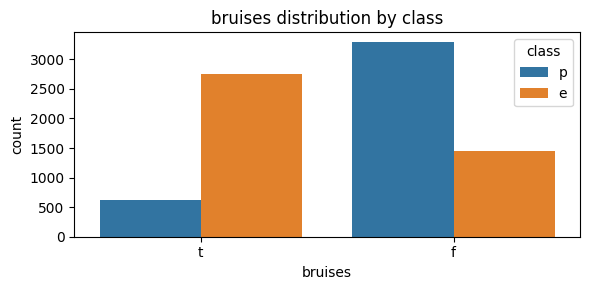

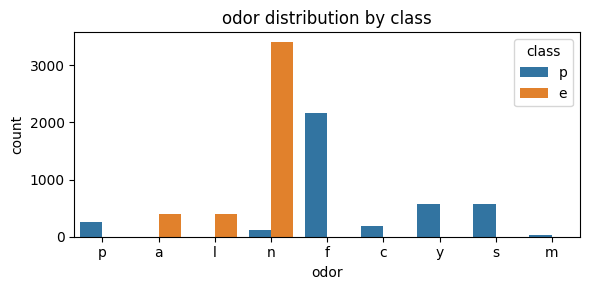

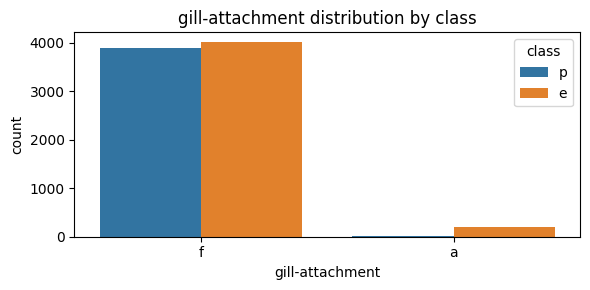

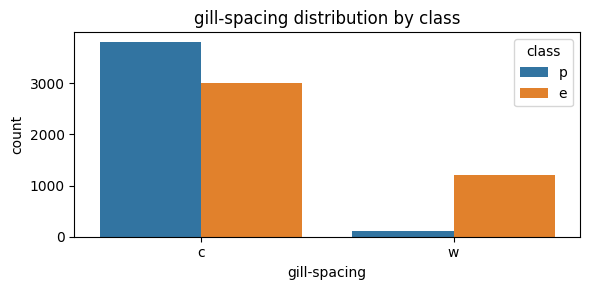

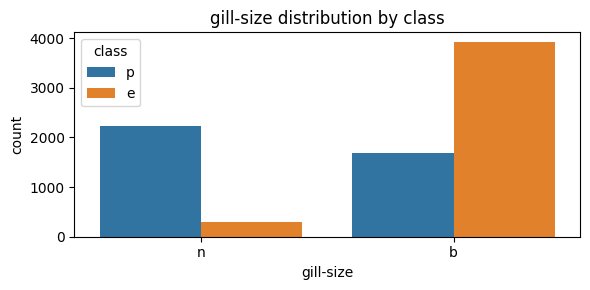

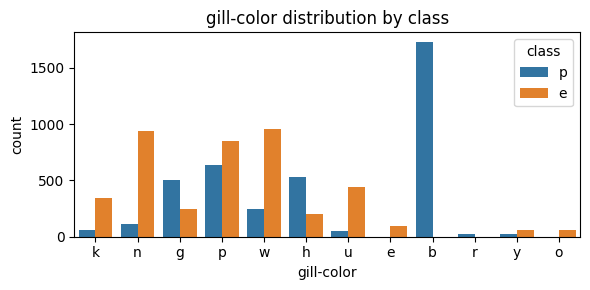

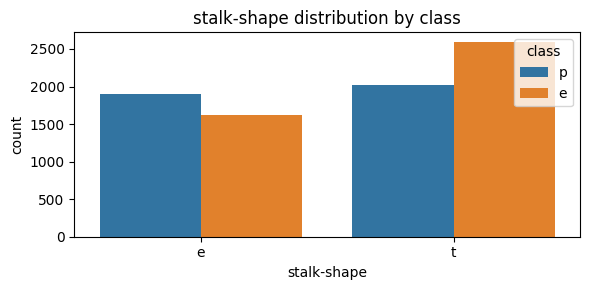

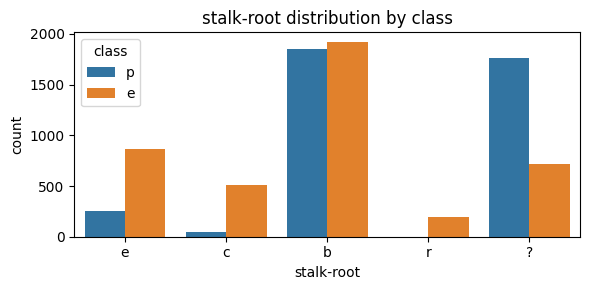

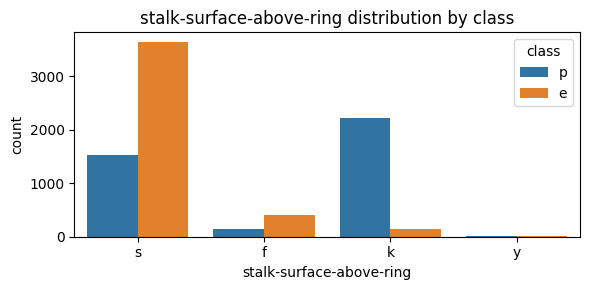

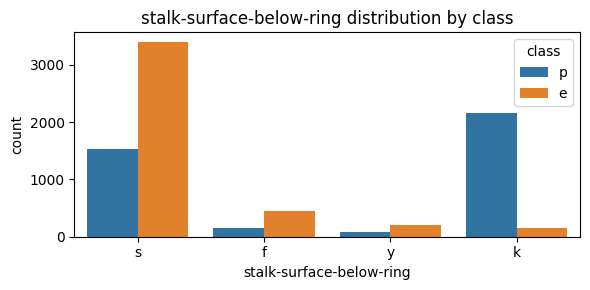

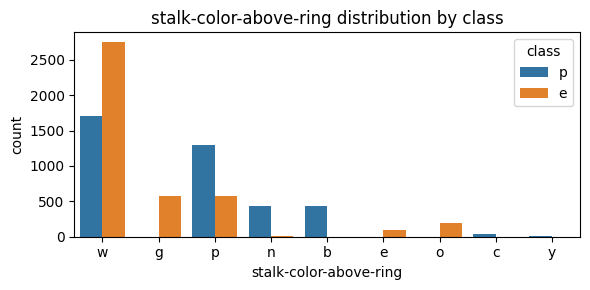

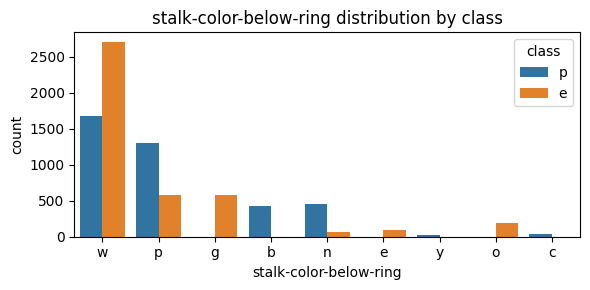

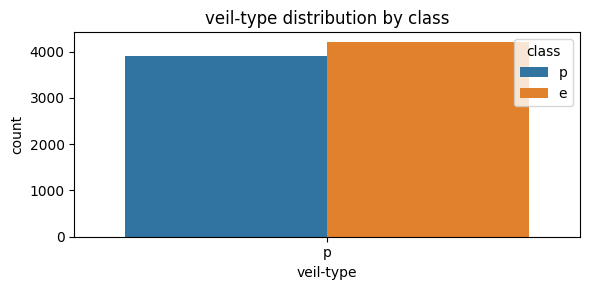

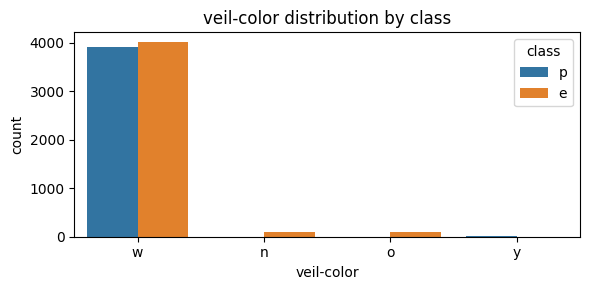

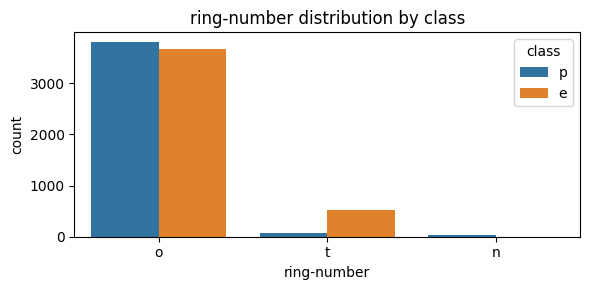

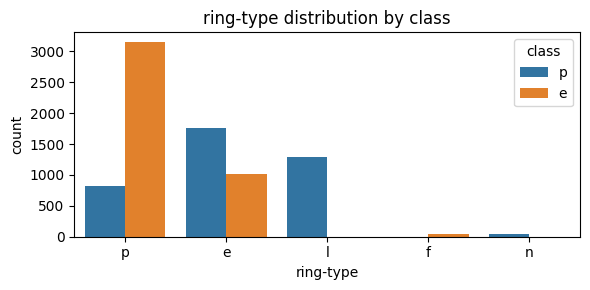

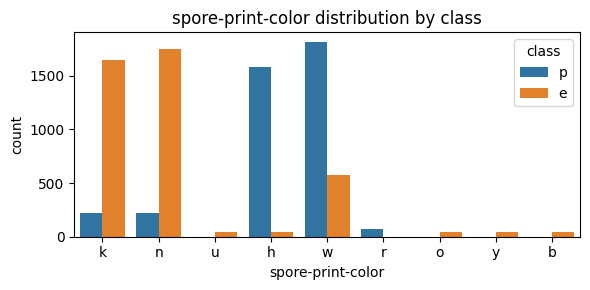

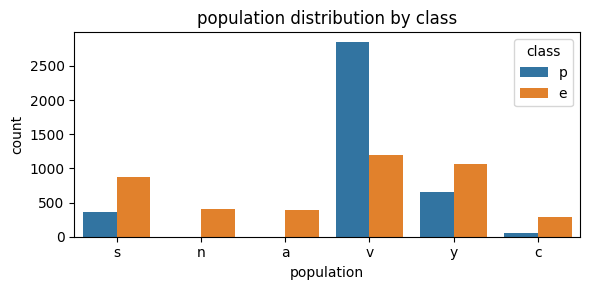

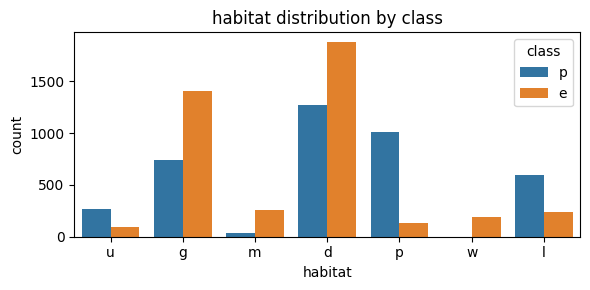

In [0]:
# Step 1: Load and Inspect Data, Explore Feature Distributions
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('/Workspace/Users/tecummateo888@gmail.com/mushrooms.csv')

# Inspect data
display(df.head())
display(df.info())

# Plot feature distributions by class for all categorical features
for col in df.columns[1:]:
    plt.figure(figsize=(6,3))
    sns.countplot(data=df, x=col, hue='class')
    plt.title(f'{col} distribution by class')
    plt.tight_layout()
    plt.show()



e,p
1.0,0.0
0.0,1.0
0.0,1.0
1.0,0.0
0.0,1.0
0.9659863945578231,0.034013605442176874
0.0,1.0
0.0,1.0
0.0,1.0


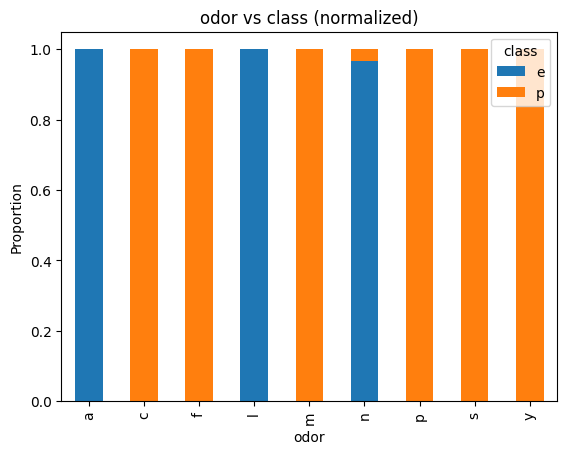

e,p
1.0,0.0
0.029411764705882353,0.9705882352941176
0.8803418803418803,0.11965811965811966
0.8861788617886179,0.11382113821138211
1.0,0.0
0.0,1.0
1.0,0.0
0.24120603015075376,0.7587939698492462
1.0,0.0


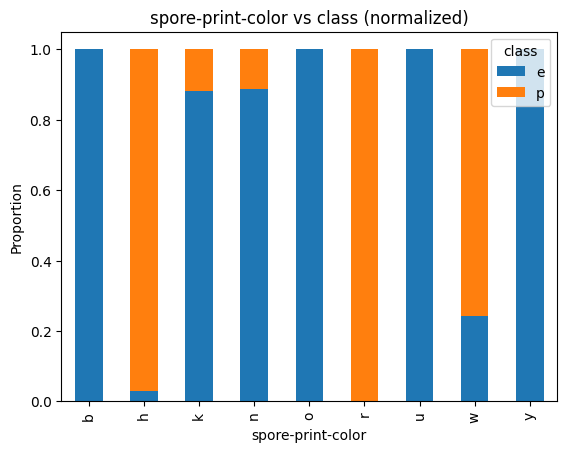

e,p
0.0,1.0
1.0,0.0
0.32978723404255317,0.6702127659574468
0.2786885245901639,0.7213114754098361
0.8431372549019608,0.1568627450980392
0.8931297709923665,0.10687022900763359
1.0,0.0
0.5710455764075067,0.4289544235924933
0.0,1.0
0.9024390243902439,0.0975609756097561


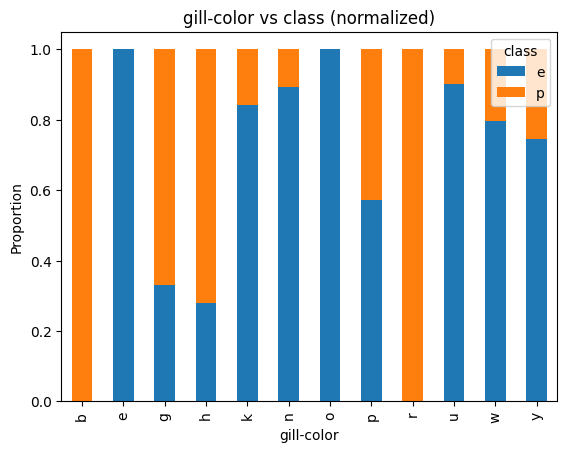

e,p
0.2903225806451613,0.7096774193548387
0.5084745762711864,0.4915254237288136
0.920863309352518,0.07913669064748201
0.7714285714285715,0.22857142857142856
1.0,0.0


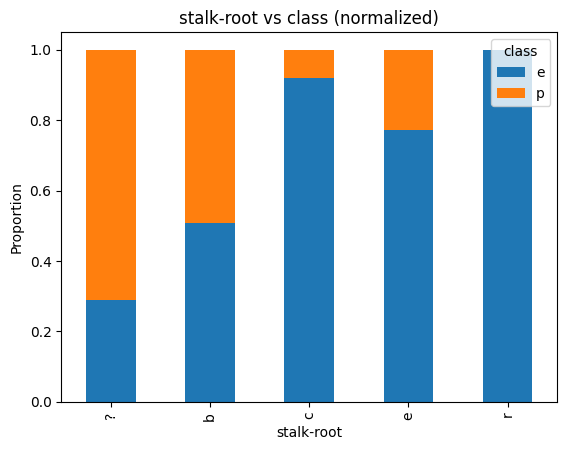

e,p
0.3631123919308357,0.6368876080691642
1.0,0.0
0.0,1.0
0.0,1.0
0.7943548387096774,0.2056451612903226


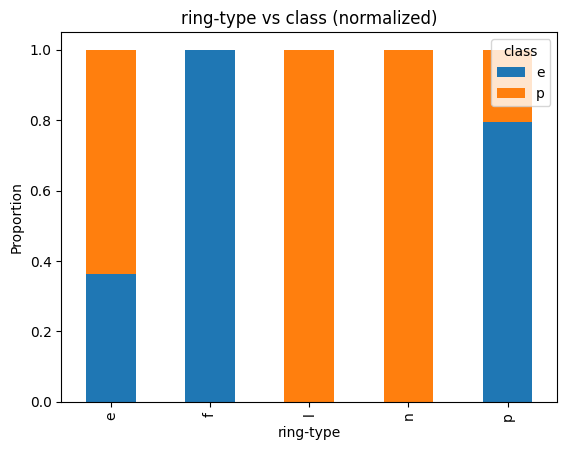

e,p
0.3066554338668913,0.6933445661331087
0.8151658767772512,0.1848341232227488


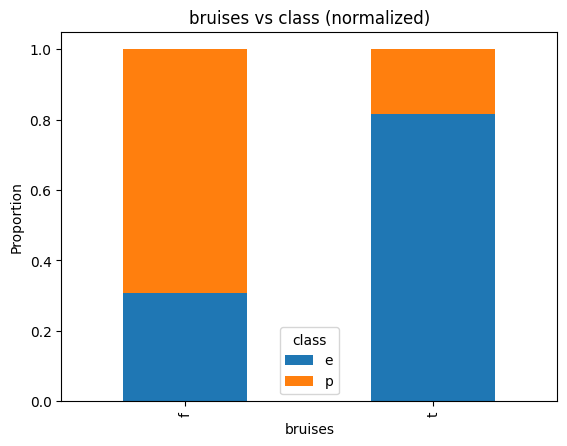

In [0]:
# Step 2: Quantify Separation with Crosstab, Identify Discriminative Features
features_to_check = ['odor', 'spore-print-color', 'gill-color', 'stalk-root', 'ring-type', 'bruises']
for feature in features_to_check:
    ct = pd.crosstab(df[feature], df['class'], normalize='index')
    display(ct)
    ct.plot(kind='bar', stacked=True)
    plt.title(f'{feature} vs class (normalized)')
    plt.ylabel('Proportion')
    plt.show()

# Identify top discriminative features visually and via crosstab
top_features = ['odor', 'spore-print-color', 'gill-color']



Test Accuracy: 99.8%
Confusion Matrix:
 [[842   0]
 [  3 780]]

Classification Report:
               precision    recall  f1-score   support

           e       1.00      1.00      1.00       842
           p       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



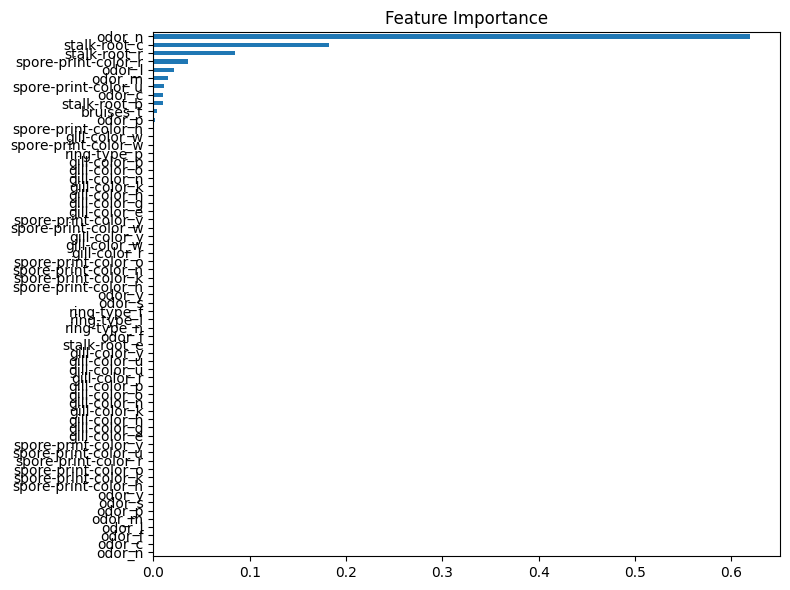

In [0]:
# Step 3: Model Training, Evaluation, Feature Importance
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Encode categorical features
X = pd.get_dummies(df[top_features + features_to_check], drop_first=True)
y = df['class']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Fit Decision Tree
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Evaluate
print(f"Test Accuracy: {np.round(100*accuracy_score(y_test, y_pred),1)}%")
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Feature importance
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot.barh(figsize=(8,6), title='Feature Importance')
plt.tight_layout()
plt.show()

<br>
<div class="alert alert-info">
<b style="font-size: 25px;">Exercise 2: The End</b>
</div>

<br>
<div class="alert alert-warning">
<b style="font-size: 25px;">Submit your notebook</b><br><br>

Before submitting, please make sure you:
- Rename the notebook by adding your name and surname at the beginning, for example: <i>Your_Name_iX_DataScience_Bootcamp_EDA_DatViz_NB1.ipynb</i>
- Save it in your folder on GitHub
- Commit and push your changes to your branch
</div>